# Commodity Price EDA — Gold, Silver, WTI Crude

Exploratory analysis for the anomaly-detection portfolio project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from project_config import TICKERS, ROLL_WINDOW, Z_THRESHOLD, MAD_SCALE, ANNUALISATION, rolling_mad

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True


## 1. Load data

In [2]:
DATA_DIR = Path("data")

dfs = {}
for key, label in TICKERS.items():
    df = pd.read_csv(DATA_DIR / f"{key}.csv", index_col="date", parse_dates=True)
    dfs[key] = df
    print(f"{label}: {df.shape[0]} rows, {df.index.min().date()} to {df.index.max().date()}")


Gold (GC=F): 2943 rows, 2015-01-02 to 2026-09-16
Silver (SI=F): 2942 rows, 2015-01-02 to 2026-09-16
WTI Crude (CL=F): 2943 rows, 2015-01-02 to 2026-09-16


## 2. Overview & data quality

In [3]:
for key, label in TICKERS.items():
    print(f"\n=== {label} ===")
    display(dfs[key].head(3))
    display(dfs[key].describe())



=== Gold (GC=F) ===


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2015-01-02,1186.000000,1186.000000,1194.500000,1169.500000,1184.000000,138
2015-01-05,1203.900024,1203.900024,1206.900024,1180.099976,1180.300049,470
2015-01-06,1219.300049,1219.300049,1220.000000,1203.500000,1203.500000,97


,Adj Close,Close,High,Low,Open,Volume
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000
mean,1945.157288,1945.157288,1959.831736,1929.724261,1944.918077,108753.665308
std,935.825491,935.825491,950.089227,920.295559,935.495208,111338.642456
min,1050.800049,1050.800049,1062.000000,1046.199951,1053.699951,0.000000
25%,1277.300049,1277.300049,1283.099976,1273.850037,1278.799988,144.000000
50%,1744.800049,1744.800049,1757.000000,1731.800049,1745.599976,120510.000000
75%,2000.400024,2000.400024,2019.299988,1987.650024,2001.900024,193567.000000
max,5318.399902,5318.399902,5586.200195,5272.899902,5415.700195,570055.000000



=== Silver (SI=F) ===


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2015-01-02,15.734000,15.734000,15.815000,15.535000,15.790000,13
2015-01-05,16.179001,16.179001,16.179001,16.179001,16.179001,0
2015-01-06,16.603001,16.603001,16.603001,16.603001,16.603001,2


,Adj Close,Close,High,Low,Open,Volume
count,2942.000000,2942.000000,2942.000000,2942.000000,2942.000000,2942.000000
mean,25.016450,25.016450,25.254455,24.796739,25.032138,1728.732835
std,14.735364,14.735364,15.121752,14.407830,14.790840,9776.164185
min,11.735000,11.735000,12.205000,11.735000,12.070000,0.000000
25%,16.510000,16.510000,16.581250,16.440751,16.510500,10.000000
50%,20.324000,20.324000,20.598499,20.170000,20.390000,48.500000
75%,26.101500,26.101500,26.291500,25.920000,26.153750,181.750000
max,115.080002,115.080002,121.300003,112.735001,116.889999,131415.000000



=== WTI Crude (CL=F) ===


,Adj Close,Close,High,Low,Open,Volume
date,,,,,,
2015-01-02,52.689999,52.689999,55.110001,52.029999,53.759998,268708
2015-01-05,50.040001,50.040001,52.730000,49.680000,52.610001,375782
2015-01-06,47.930000,47.930000,50.369999,47.549999,50.000000,451642


,Adj Close,Close,High,Low,Open,Volume
count,2943.000000,2943.000000,2943.000000,2943.000000,2943.000000,2.943000e+03
mean,63.508468,63.508468,64.679881,62.331590,63.545518,4.372394e+05
std,17.909558,17.909558,18.233240,17.539626,17.886493,2.153201e+05
min,-37.630001,-37.630001,13.690000,-40.320000,-14.000000,0.000000e+00
25%,50.174999,50.174999,50.985001,49.410000,50.220001,2.910710e+05
50%,62.369999,62.369999,63.400002,61.480000,62.310001,3.900870e+05
75%,74.645000,74.645000,76.070000,73.435001,74.689999,5.703080e+05
max,123.699997,123.699997,130.500000,120.790001,124.660004,2.288230e+06


In [4]:
quality_summary = []
for key, label in TICKERS.items():
    df = dfs[key]
    quality_summary.append({
        "commodity": label,
        "rows": len(df),
        "nan_rows": df.isna().any(axis=1).sum(),
        "zero_volume_rows": (df["Volume"] == 0).sum() if "Volume" in df.columns else np.nan,
        "pct_zero_volume": round((df["Volume"] == 0).mean() * 100, 2) if "Volume" in df.columns else np.nan,
    })

pd.DataFrame(quality_summary)


,commodity,rows,nan_rows,zero_volume_rows,pct_zero_volume
0,Gold (GC=F),2943,0,36,1.22
1,Silver (SI=F),2942,0,189,6.42
2,WTI Crude (CL=F),2943,0,7,0.24


## 3. Price trends over time

A first look at each series to sanity-check overall shape before diving into returns.

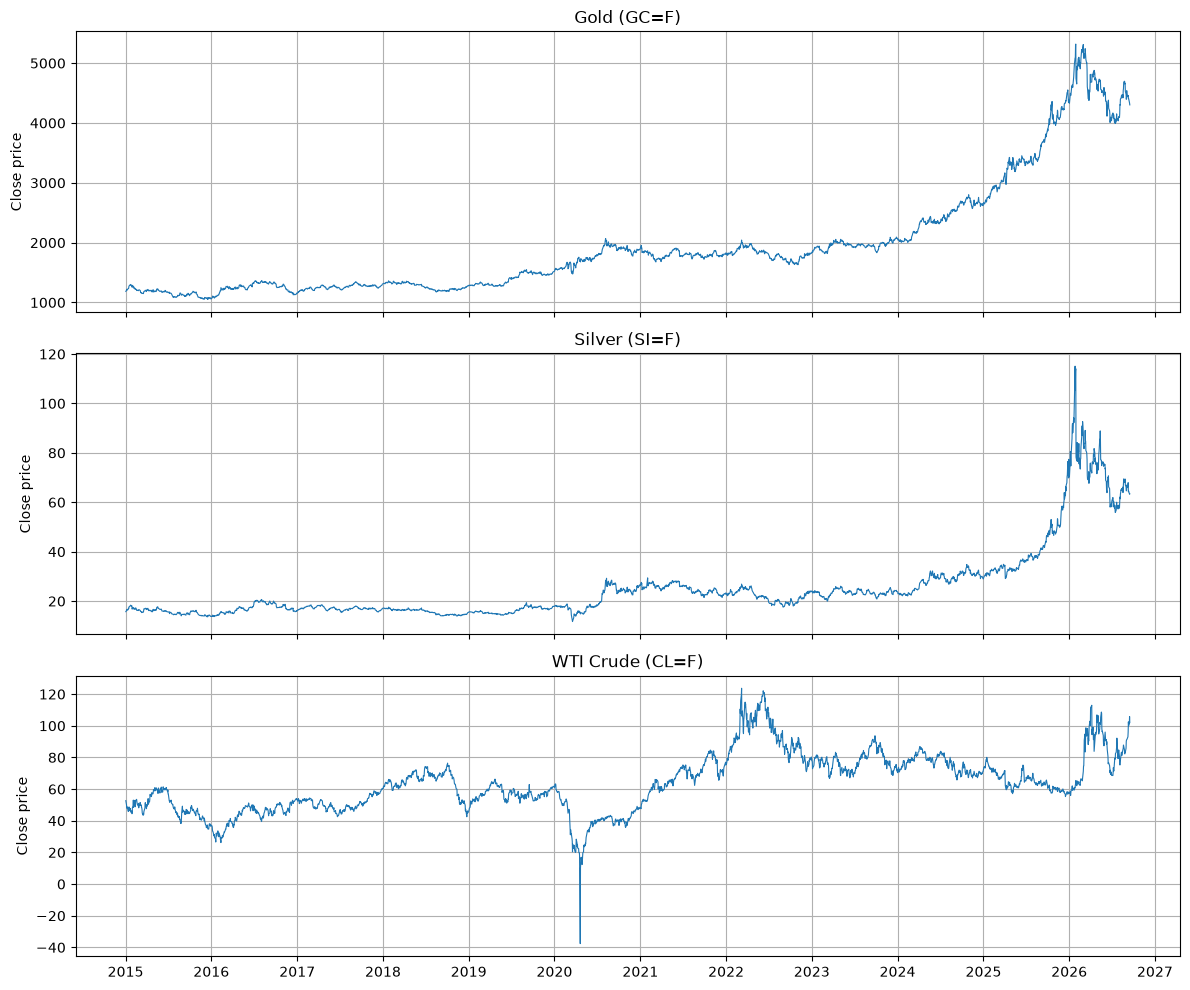

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, (key, label) in zip(axes, TICKERS.items()):
    ax.plot(dfs[key].index, dfs[key]["Close"], linewidth=0.8)
    ax.set_title(label)
    ax.set_ylabel("Close price")
axes[-1].xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


## 4. Daily returns

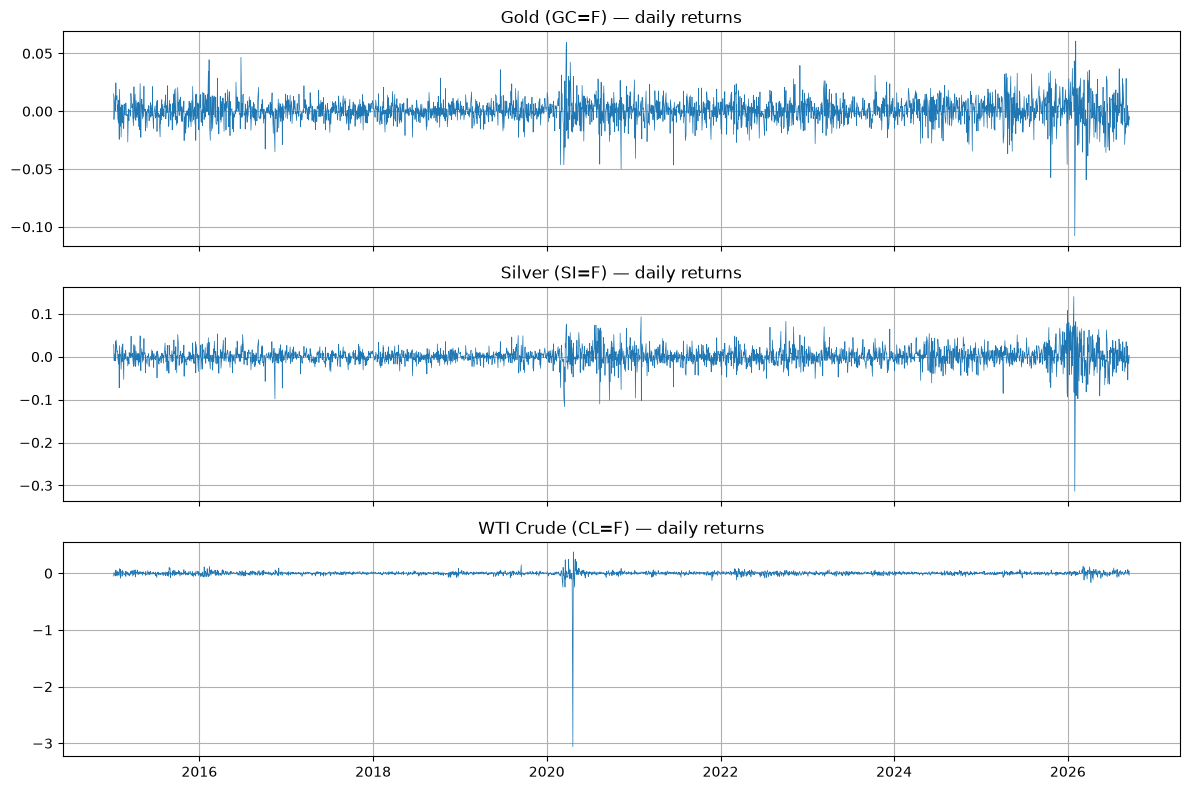

In [6]:
returns = {}
for key in TICKERS:
    close = dfs[key]["Close"]
    returns[key] = close.pct_change().dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, (key, label) in zip(axes, TICKERS.items()):
    ax.plot(returns[key].index, returns[key], linewidth=0.5)
    ax.set_title(f"{label} — daily returns")
plt.tight_layout()
plt.show()


## 5. Return distribution

In [7]:
stats_summary = []
for key, label in TICKERS.items():
    r = returns[key]
    stats_summary.append({
        "commodity": label,
        "mean": r.mean(),
        "std": r.std(),
        "skew": r.skew(),
        "kurtosis": r.kurtosis(),  # excess kurtosis; >0 means fatter tails than normal
        "min": r.min(),
        "max": r.max(),
    })

pd.DataFrame(stats_summary).set_index("commodity")


,mean,std,skew,kurtosis,min,max
commodity,,,,,,
Gold (GC=F),0.000494,0.010559,-0.439785,6.987277,-0.107796,0.060697
Silver (SI=F),0.000701,0.021079,-1.221313,20.618050,-0.313468,0.140253
WTI Crude (CL=F),-0.000611,0.067802,-33.373119,1451.001065,-3.059661,0.376623


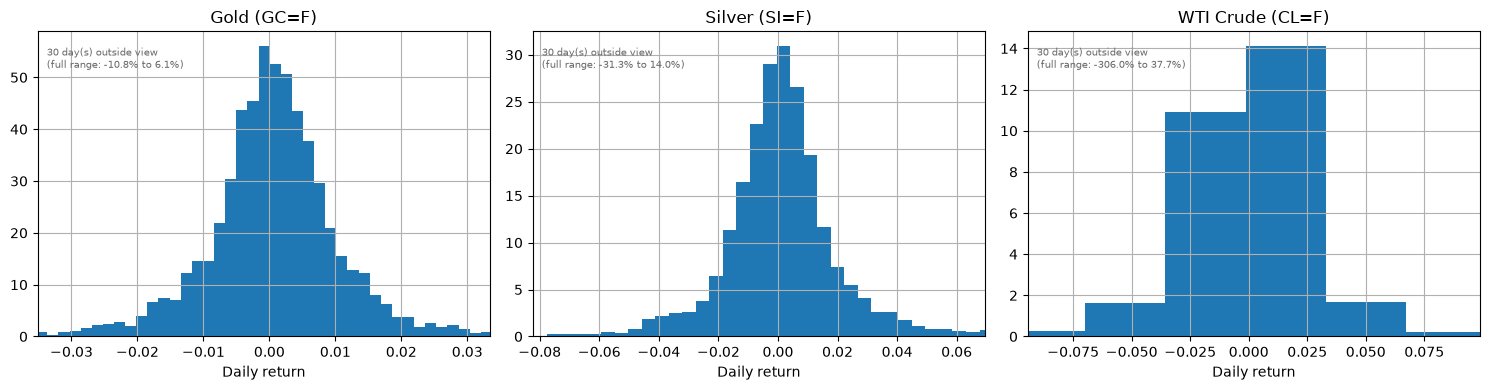

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, label) in zip(axes, TICKERS.items()):
    r = returns[key]

    # Display range clipped to the 0.5th-99.5th percentile so the bulk of the
    # distribution stays readable. Histogram BINS still use the full data — this
    # only affects what's visible on the x-axis, not the underlying calculation.
    lo, hi = r.quantile([0.005, 0.995])

    ax.hist(r, bins=100, density=True)
    ax.set_xlim(lo, hi)
    ax.set_title(label)
    ax.set_xlabel("Daily return")

    n_clipped = int(((r < lo) | (r > hi)).sum())
    if n_clipped:
        ax.text(0.02, 0.95, f"{n_clipped} day(s) outside view\n(full range: {r.min():.1%} to {r.max():.1%})",
                transform=ax.transAxes, fontsize=7, va="top", color="dimgray")
plt.tight_layout()
plt.show()


**Read on kurtosis:** all three should show excess kurtosis well above 0 (fat tails) —
expected for commodities and part of why a normal-distribution z-score is a first-pass tool,
not a final one. Ruptures/Isolation Forest in the next stage should pick up what a symmetric
z-score threshold misses.

## 6. Rolling volatility

10-day and 30-day realised volatility (annualised) — shows *when* each market was turbulent,
independent of direction.

**Log y-axis, deliberately:** WTI's post-2020-04-20 volatility spike is large enough to
compress the rest of that panel's history down near zero on a linear scale. A log scale keeps
every data point visible (nothing is hidden or clipped) while making the whole history
readable at once.

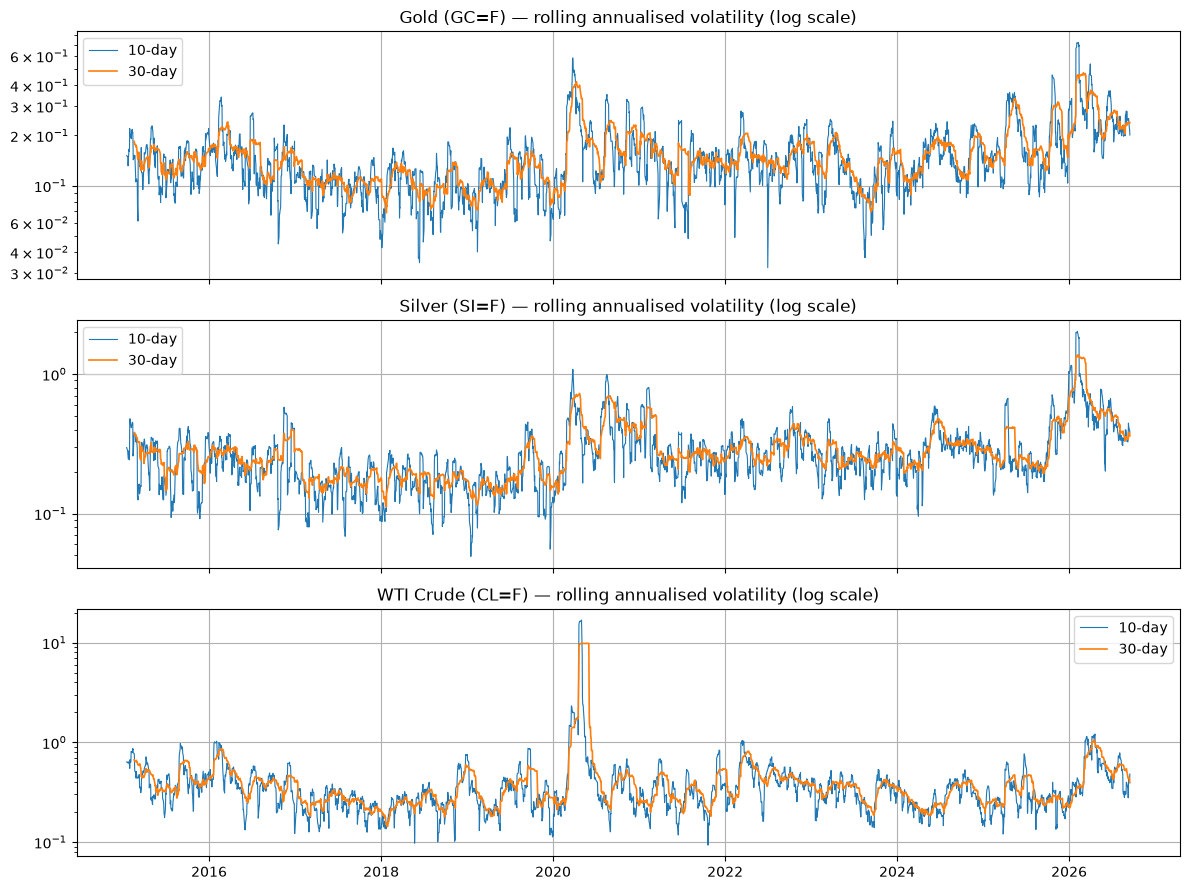

In [9]:
vol = {}
for key in TICKERS:
    r = returns[key]
    vol[key] = pd.DataFrame({
        "vol_10d": r.rolling(10).std() * ANNUALISATION,
        "vol_30d": r.rolling(30).std() * ANNUALISATION,
    })

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (key, label) in zip(axes, TICKERS.items()):
    ax.plot(vol[key].index, vol[key]["vol_10d"], label="10-day", linewidth=0.8)
    ax.plot(vol[key].index, vol[key]["vol_30d"], label="30-day", linewidth=1.2)
    ax.set_yscale("log")
    ax.set_title(f"{label} — rolling annualised volatility (log scale)")
    ax.legend()
plt.tight_layout()
plt.show()


## 7. Extreme-move flagging (robust rolling z-score)

In [10]:
# Original mean/std z-score — kept only as a reference point for the sweep below
flags_std = {}
z_robust = {}  # not yet thresholded — reused by the sweep and the final flagging step

for key in TICKERS:
    r = returns[key]

    roll_mean = r.rolling(ROLL_WINDOW).mean()
    roll_std = r.rolling(ROLL_WINDOW).std()
    z_std = (r - roll_mean) / roll_std
    flags_std[key] = r[z_std.abs() > 3.0]

    roll_median = r.rolling(ROLL_WINDOW).median()
    roll_mad = rolling_mad(r, ROLL_WINDOW) * MAD_SCALE
    z_robust[key] = (r - roll_median) / roll_mad.replace(0, np.nan)


In [11]:
check_date = pd.Timestamp("2020-04-21")

for candidate in [3.0, 3.5, 4.0, 4.5, 5.0]:
    print(f"--- Z_THRESHOLD = {candidate} ---")
    for key in TICKERS:
        flagged_mask = z_robust[key].abs() > candidate
        n_flagged = flagged_mask.sum()
        note = ""
        if key == "wti_crude":
            caught = check_date in returns[key][flagged_mask].index
            note = f" | 2020-04-21 caught: {caught}"
        print(f"  {TICKERS[key]}: {n_flagged} flagged{note}")


--- Z_THRESHOLD = 3.0 ---
  Gold (GC=F): 109 flagged
  Silver (SI=F): 121 flagged
  WTI Crude (CL=F): 90 flagged | 2020-04-21 caught: True
--- Z_THRESHOLD = 3.5 ---
  Gold (GC=F): 58 flagged
  Silver (SI=F): 78 flagged
  WTI Crude (CL=F): 60 flagged | 2020-04-21 caught: True
--- Z_THRESHOLD = 4.0 ---
  Gold (GC=F): 38 flagged
  Silver (SI=F): 48 flagged
  WTI Crude (CL=F): 39 flagged | 2020-04-21 caught: True
--- Z_THRESHOLD = 4.5 ---
  Gold (GC=F): 24 flagged
  Silver (SI=F): 25 flagged
  WTI Crude (CL=F): 30 flagged | 2020-04-21 caught: True
--- Z_THRESHOLD = 5.0 ---
  Gold (GC=F): 21 flagged
  Silver (SI=F): 17 flagged
  WTI Crude (CL=F): 21 flagged | 2020-04-21 caught: True


Pick the smallest threshold from the sweep above that still catches 2020-04-21 and brings
the flagged counts back down close to the original std-based numbers (27 / 33 / 38).

**If a different value looks better than the current default, update `Z_THRESHOLD` in
`project_config.py`** (not here) — that's the one place both notebooks read it from, so the
change carries through automatically rather than needing to be repeated in each file.

In [12]:
flags = {}
for key in TICKERS:
    flags[key] = returns[key][z_robust[key].abs() > Z_THRESHOLD]
    print(f"{TICKERS[key]}: {len(flags[key])} flagged (robust MAD-based, threshold={Z_THRESHOLD}, "
          f"from project_config) vs {len(flags_std[key])} flagged (original std-based, threshold=3.0)")


Gold (GC=F): 38 flagged (robust MAD-based, threshold=4.0, from project_config) vs 27 flagged (original std-based, threshold=3.0)
Silver (SI=F): 48 flagged (robust MAD-based, threshold=4.0, from project_config) vs 33 flagged (original std-based, threshold=3.0)
WTI Crude (CL=F): 39 flagged (robust MAD-based, threshold=4.0, from project_config) vs 38 flagged (original std-based, threshold=3.0)


In [13]:
# Direct check: does the current (config-driven) threshold still catch the day std-based missed?
if check_date in flags["wti_crude"].index:
    print(f"2020-04-21 IS flagged (return = {flags['wti_crude'][check_date]:.1%})")
else:
    print("2020-04-21 NOT flagged at the current Z_THRESHOLD — consider lowering it in project_config.py")


2020-04-21 IS flagged (return = -126.6%)


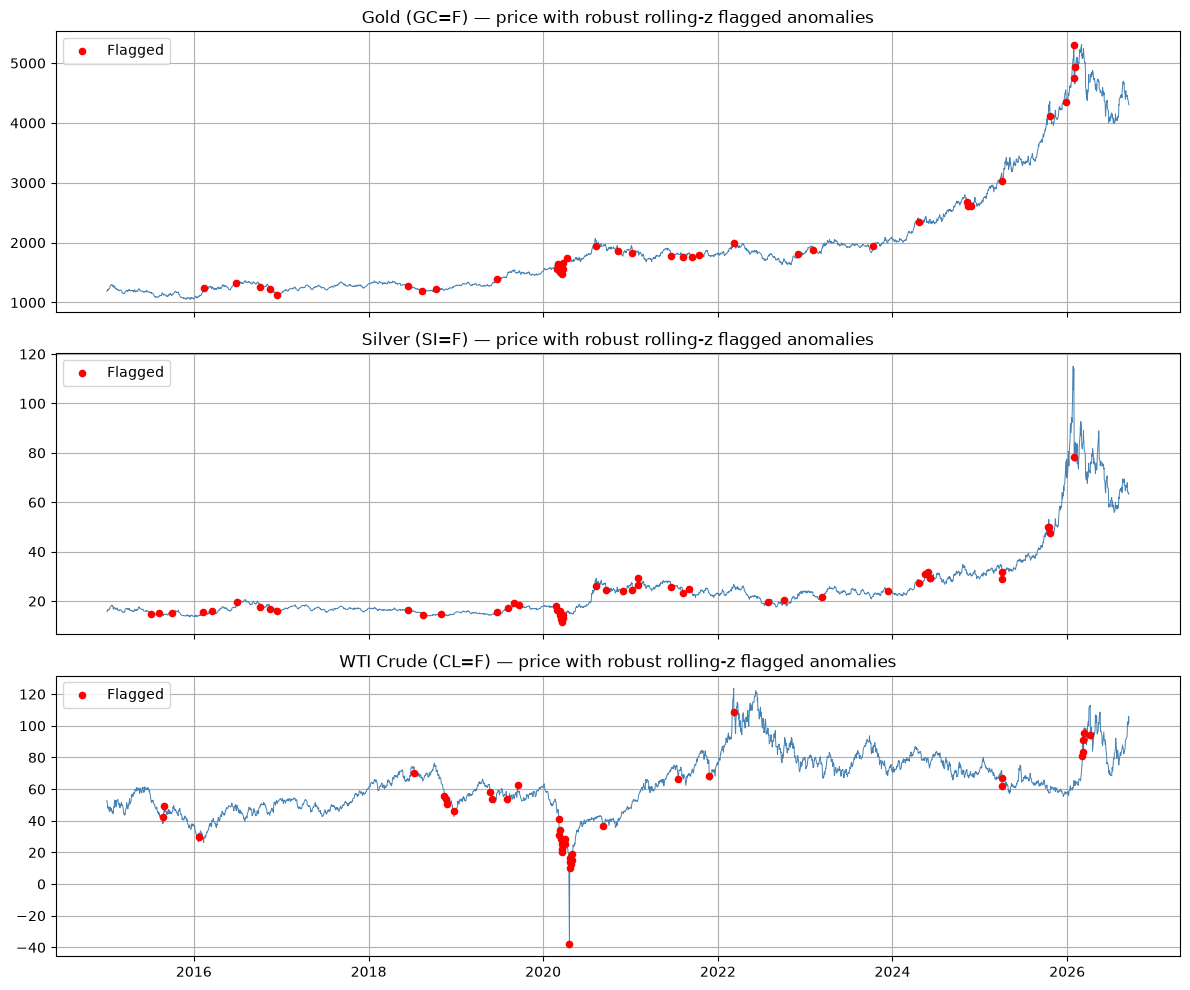

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, (key, label) in zip(axes, TICKERS.items()):
    close = dfs[key]["Close"]
    ax.plot(close.index, close, linewidth=0.7, color="steelblue")
    flagged_dates = flags[key].index
    ax.scatter(flagged_dates, close.loc[flagged_dates], color="red", s=20, zorder=5, label="Flagged")
    ax.set_title(f"{label} — price with robust rolling-z flagged anomalies")
    ax.legend()
plt.tight_layout()
plt.show()


## 8. Volume quality check

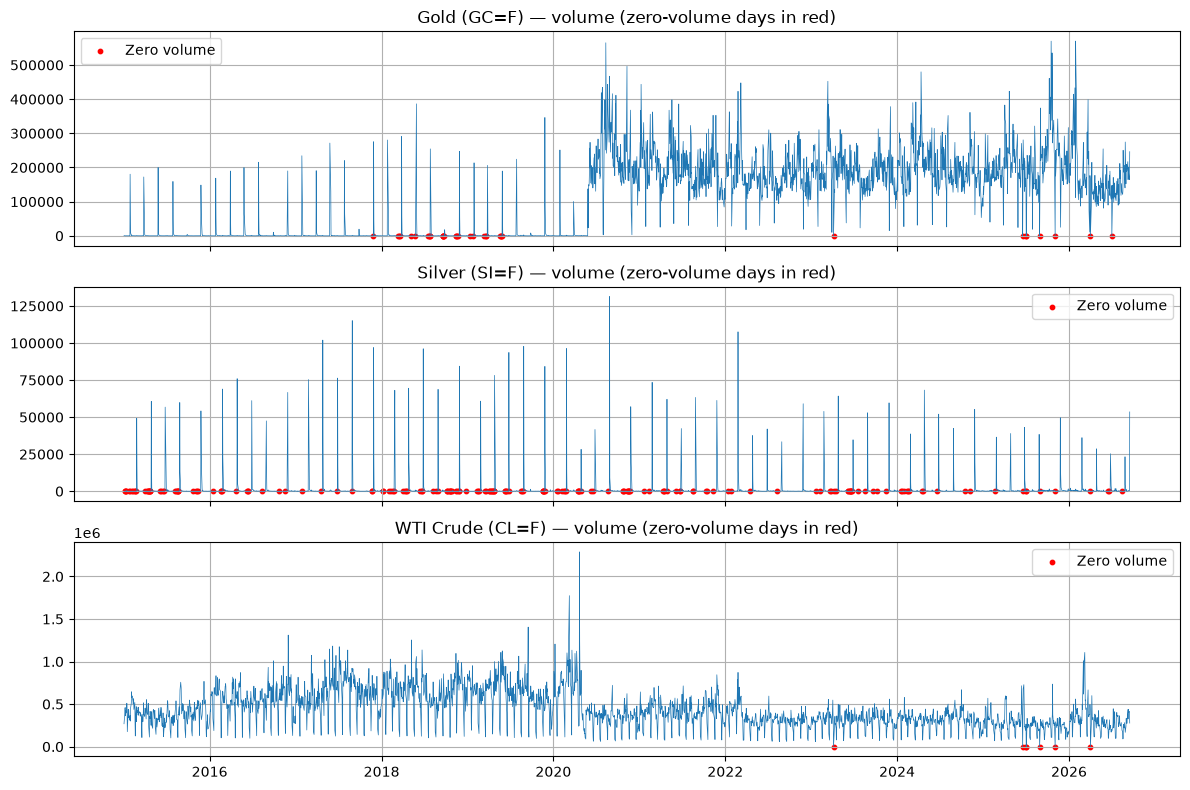

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, (key, label) in zip(axes, TICKERS.items()):
    vol_series = dfs[key]["Volume"]
    ax.plot(vol_series.index, vol_series, linewidth=0.5)
    zero_days = vol_series[vol_series == 0]
    ax.scatter(zero_days.index, zero_days, color="red", s=10, label="Zero volume")
    ax.set_title(f"{label} — volume (zero-volume days in red)")
    ax.legend()
plt.tight_layout()
plt.show()


In [16]:
# Check whether zero-volume days are scattered or clustered in runs —
# a long consecutive run points to a reporting gap rather than genuinely quiet days.
for key, label in TICKERS.items():
    zero_mask = (dfs[key]["Volume"] == 0).astype(int)
    run_lengths = zero_mask.groupby((zero_mask != zero_mask.shift()).cumsum()).sum()
    longest_run = run_lengths[run_lengths > 0].max() if (run_lengths > 0).any() else 0
    print(f"{label}: longest consecutive zero-volume run = {longest_run} day(s)")


Gold (GC=F): longest consecutive zero-volume run = 4 day(s)
Silver (SI=F): longest consecutive zero-volume run = 6 day(s)
WTI Crude (CL=F): longest consecutive zero-volume run = 2 day(s)


## 9. Cross-commodity correlation

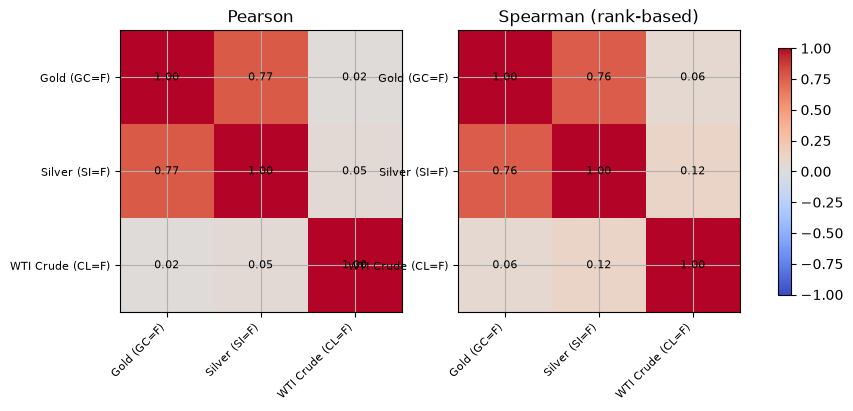

In [17]:
returns_df = pd.DataFrame({key: returns[key] for key in TICKERS}).dropna()

corr_pearson = returns_df.corr(method="pearson")
corr_spearman = returns_df.corr(method="spearman")
corr_pearson.columns = corr_pearson.index = list(TICKERS.values())
corr_spearman.columns = corr_spearman.index = list(TICKERS.values())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, corr, title in zip(axes, [corr_pearson, corr_spearman], ["Pearson", "Spearman (rank-based)"]):
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr)))
    ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()
